# Trace Analysis Visualization

Visualize kernel performance metrics from PyTorch profiler traces:
- Kernel category breakdown (compute/communication/memory)
- GPU idle time analysis
- Phase distribution (prefill/decode)
- Cross-rank performance comparison

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Output directory for figures
output_dir = Path('figures')
output_dir.mkdir(exist_ok=True)

print(f"Figures will be saved to: {output_dir}")

Figures will be saved to: figures


## 1. Load Data

In [2]:
# Load trace data
df_summary = pd.read_csv('data/trace_summary.csv')
print(f"Loaded {len(df_summary)} per-rank summaries")

# Try to load cross-rank data if available
try:
    df_cross = pd.read_csv('data/trace_cross_rank.csv')
    print(f"Loaded {len(df_cross)} cross-rank summaries")
    has_cross_rank = True
except FileNotFoundError:
    print("Cross-rank data not yet available (will be generated when export completes)")
    has_cross_rank = False

# Display basic info
print("\nConfigurations in data:")
configs = df_summary.groupby(['tp_size', 'ep_size', 'dp_size']).size().reset_index(name='ranks')
print(configs)

Loaded 33 per-rank summaries
Loaded 11 cross-rank summaries

Configurations in data:
   tp_size  ep_size  dp_size  ranks
0        8        8        1      6
1        8        8        4      3
2        8        8        8      3
3       16        4        1      3
4       16        8        1      3
5       16       16        1      3
6       16       16       16      3
7       32        8        1      3
8       32       16        1      3
9       32       32        1      3


## 2. Kernel Category Breakdown by Configuration

Stacked bar chart showing compute/communication/memory percentages for each parallelism configuration.

In [3]:
# Aggregate by configuration
config_cols = ['tp_size', 'ep_size', 'dp_size']
agg_data = df_summary.groupby(config_cols).agg({
    'communication_time_pct': 'mean',
    'memory_time_pct': 'mean',
    'compute_time_pct': 'mean',
    'gpu_idle_pct': 'mean'
}).reset_index()

# Create config labels
agg_data['config'] = agg_data.apply(
    lambda x: f"TP{int(x['tp_size'])}-EP{int(x['ep_size'])}-DP{int(x['dp_size'])}", 
    axis=1
)

# Sort by total parallelism (tp*ep*dp)
agg_data['total_gpus'] = agg_data.apply(lambda x: max(int(x['tp_size']), int(x['ep_size']), int(x['dp_size'])), axis=1)
agg_data = agg_data.sort_values('total_gpus')

print("\nAggregated data by configuration:")
print(agg_data[['config', 'communication_time_pct', 'memory_time_pct', 'compute_time_pct', 'gpu_idle_pct']].to_string(index=False))


Aggregated data by configuration:
        config  communication_time_pct  memory_time_pct  compute_time_pct  gpu_idle_pct
   TP8-EP8-DP1               79.620972         0.250421         20.128606     83.053569
   TP8-EP8-DP4               93.089804         0.148287          6.761910     68.632409
   TP8-EP8-DP8               86.007950         0.319443         13.672607     46.830778
  TP16-EP4-DP1                0.000000         0.000000          0.000000      0.000000
  TP16-EP8-DP1               66.934868         0.017532         33.047601     74.510258
 TP16-EP16-DP1               63.973333         0.015939         36.010728     57.449395
TP16-EP16-DP16               88.193545         0.285884         11.520571     66.655557
  TP32-EP8-DP1               61.326742         0.099260         38.573998     21.018560
 TP32-EP16-DP1               83.276442         0.009046         16.714512     64.601480
 TP32-EP32-DP1               74.856396         0.013577         25.130027     68.6417

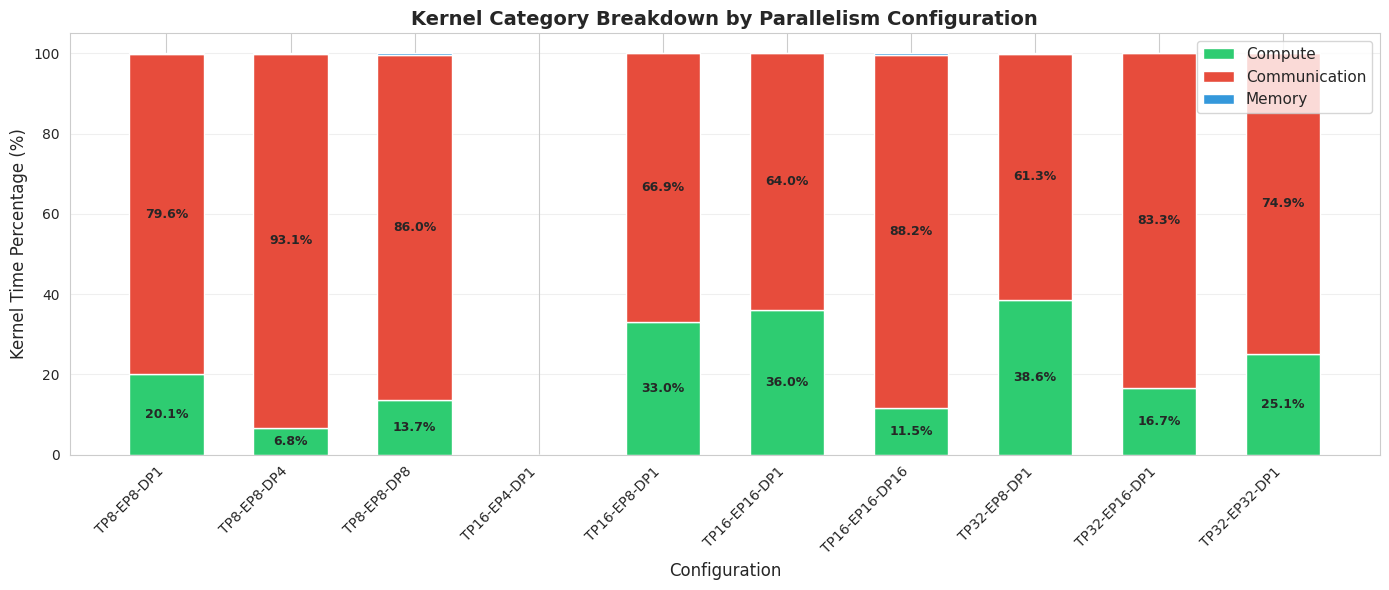


Saved: figures/kernel_category_breakdown.png


In [4]:
# Stacked bar chart for kernel categories
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(agg_data))
width = 0.6

# Plot stacked bars
p1 = ax.bar(x, agg_data['compute_time_pct'], width, label='Compute', color='#2ecc71')
p2 = ax.bar(x, agg_data['communication_time_pct'], width, 
            bottom=agg_data['compute_time_pct'], label='Communication', color='#e74c3c')
p3 = ax.bar(x, agg_data['memory_time_pct'], width,
            bottom=agg_data['compute_time_pct'] + agg_data['communication_time_pct'], 
            label='Memory', color='#3498db')

# Customize
ax.set_ylabel('Kernel Time Percentage (%)', fontsize=12)
ax.set_xlabel('Configuration', fontsize=12)
ax.set_title('Kernel Category Breakdown by Parallelism Configuration', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(agg_data['config'], rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, (comp, comm, mem) in enumerate(zip(agg_data['compute_time_pct'], 
                                            agg_data['communication_time_pct'],
                                            agg_data['memory_time_pct'])):
    if comp > 5:  # Only show if segment is large enough
        ax.text(i, comp/2, f'{comp:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold')
    if comm > 5:
        ax.text(i, comp + comm/2, f'{comm:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / 'kernel_category_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {output_dir / 'kernel_category_breakdown.png'}")

## 3. GPU Idle Time Analysis

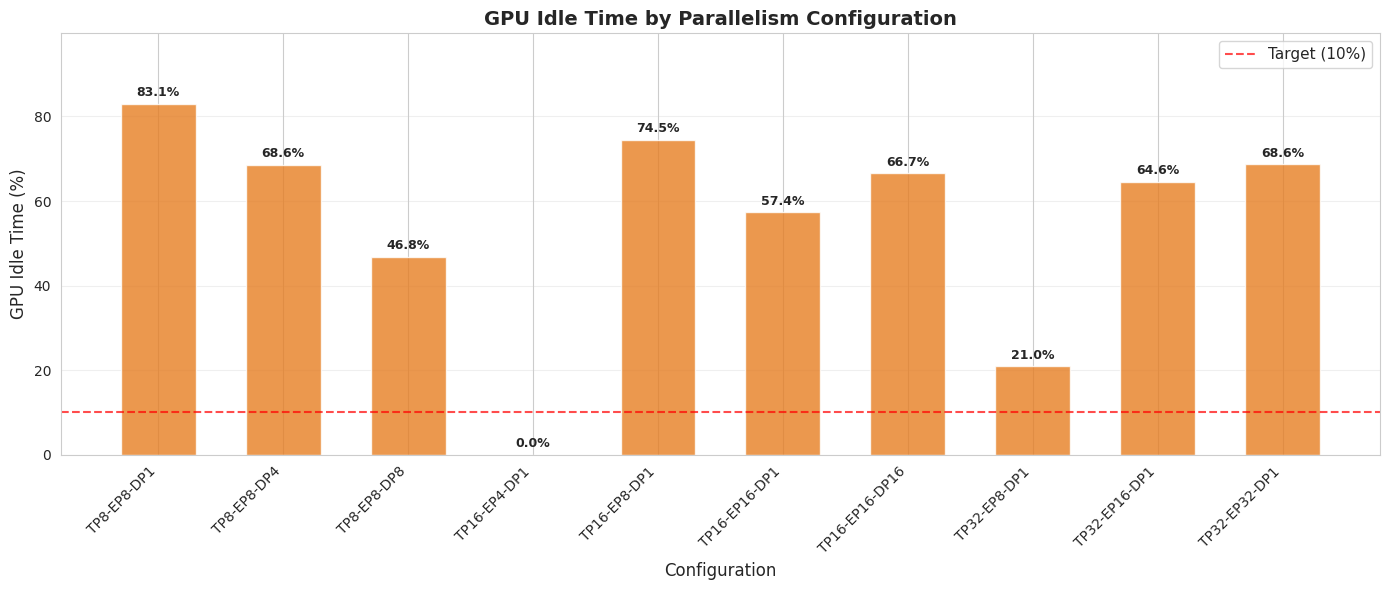


Saved: figures/gpu_idle_time.png


In [5]:
# GPU idle time comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(agg_data))
width = 0.6

bars = ax.bar(x, agg_data['gpu_idle_pct'], width, color='#e67e22', alpha=0.8)

# Customize
ax.set_ylabel('GPU Idle Time (%)', fontsize=12)
ax.set_xlabel('Configuration', fontsize=12)
ax.set_title('GPU Idle Time by Parallelism Configuration', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(agg_data['config'], rotation=45, ha='right')
ax.set_ylim(0, max(agg_data['gpu_idle_pct']) * 1.2)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, agg_data['gpu_idle_pct'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add reference line for target idle time (e.g., 10%)
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Target (10%)', alpha=0.7)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(output_dir / 'gpu_idle_time.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {output_dir / 'gpu_idle_time.png'}")

## 4. Prefill vs Decode Phase Distribution

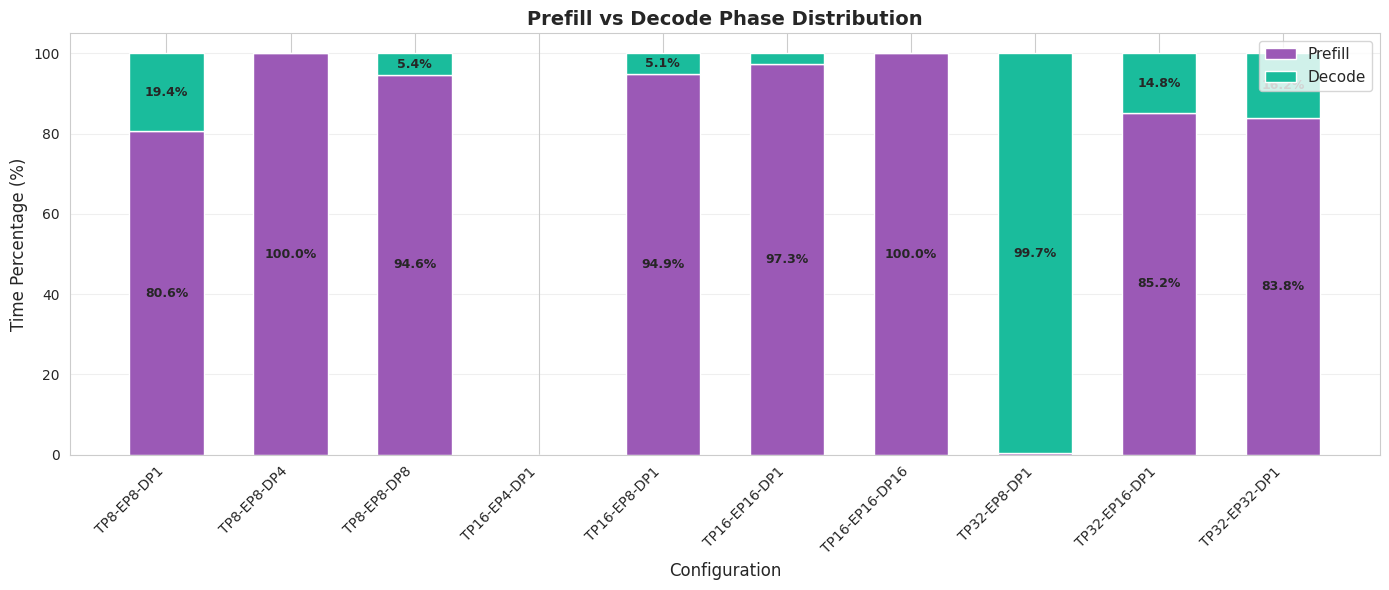


Saved: figures/prefill_decode_distribution.png


In [6]:
# Phase distribution
phase_data = df_summary.groupby(config_cols).agg({
    'prefill_time_pct': 'mean',
    'decode_time_pct': 'mean'
}).reset_index()

phase_data['config'] = phase_data.apply(
    lambda x: f"TP{int(x['tp_size'])}-EP{int(x['ep_size'])}-DP{int(x['dp_size'])}", 
    axis=1
)

# Sort same as before
phase_data['total_gpus'] = phase_data.apply(lambda x: max(int(x['tp_size']), int(x['ep_size']), int(x['dp_size'])), axis=1)
phase_data = phase_data.sort_values('total_gpus')

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(phase_data))
width = 0.6

# Plot stacked bars
p1 = ax.bar(x, phase_data['prefill_time_pct'], width, label='Prefill', color='#9b59b6')
p2 = ax.bar(x, phase_data['decode_time_pct'], width, 
            bottom=phase_data['prefill_time_pct'], label='Decode', color='#1abc9c')

# Customize
ax.set_ylabel('Time Percentage (%)', fontsize=12)
ax.set_xlabel('Configuration', fontsize=12)
ax.set_title('Prefill vs Decode Phase Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(phase_data['config'], rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (prefill, decode) in enumerate(zip(phase_data['prefill_time_pct'], 
                                            phase_data['decode_time_pct'])):
    if prefill > 5:
        ax.text(i, prefill/2, f'{prefill:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold')
    if decode > 5:
        ax.text(i, prefill + decode/2, f'{decode:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / 'prefill_decode_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {output_dir / 'prefill_decode_distribution.png'}")

## 5. Combined View: Category + Idle Time

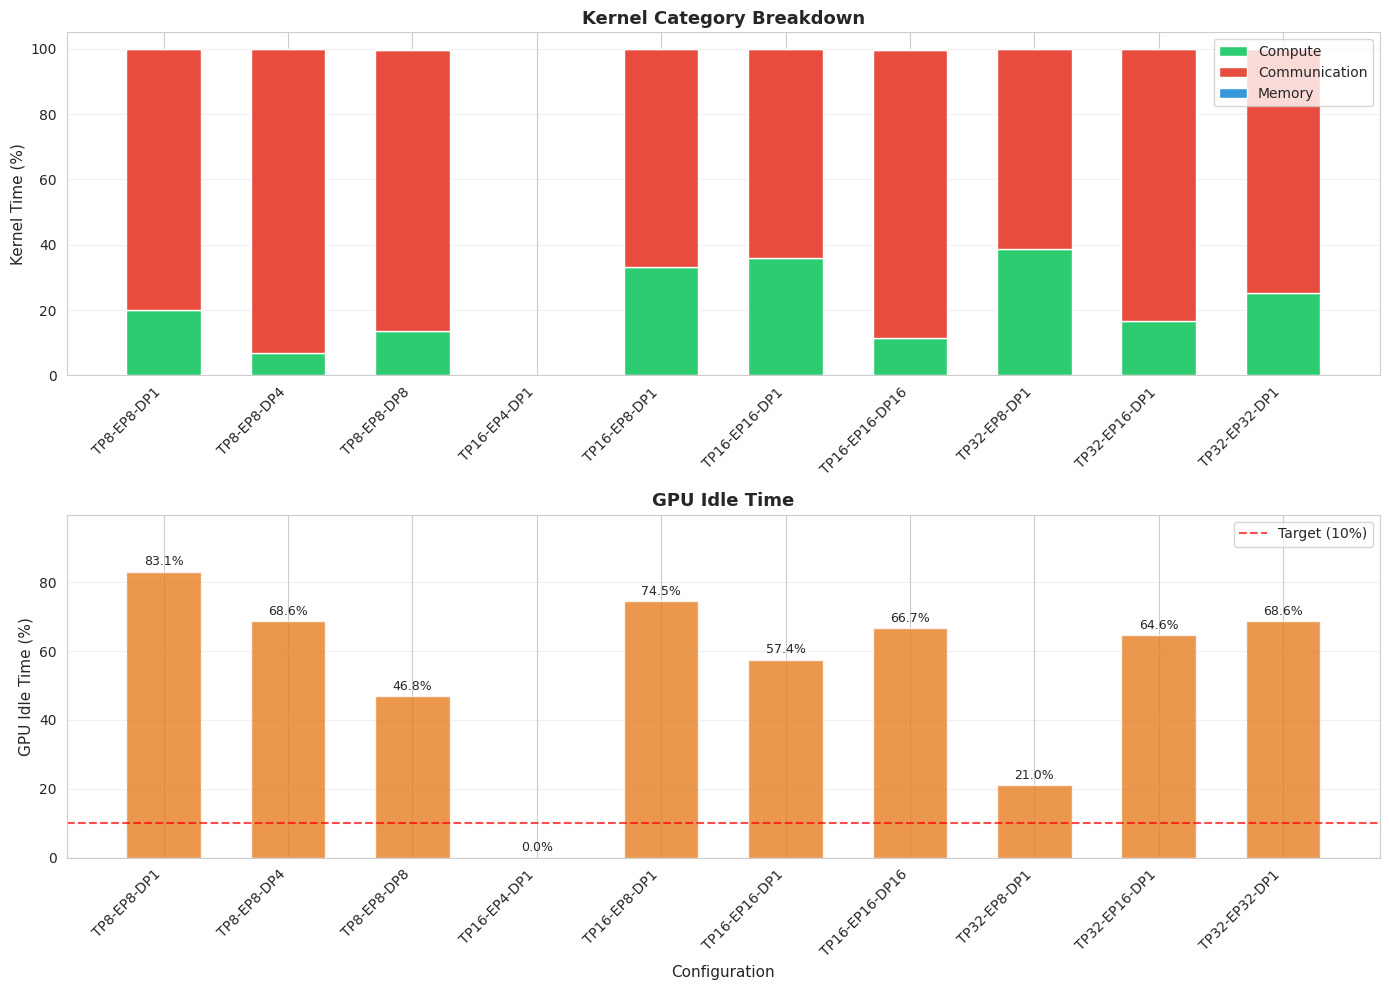


Saved: figures/combined_category_idle.png


In [7]:
# Combined figure with category breakdown and idle time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top: Category breakdown
x = np.arange(len(agg_data))
width = 0.6

ax1.bar(x, agg_data['compute_time_pct'], width, label='Compute', color='#2ecc71')
ax1.bar(x, agg_data['communication_time_pct'], width, 
        bottom=agg_data['compute_time_pct'], label='Communication', color='#e74c3c')
ax1.bar(x, agg_data['memory_time_pct'], width,
        bottom=agg_data['compute_time_pct'] + agg_data['communication_time_pct'], 
        label='Memory', color='#3498db')

ax1.set_ylabel('Kernel Time (%)', fontsize=11)
ax1.set_title('Kernel Category Breakdown', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(agg_data['config'], rotation=45, ha='right')
ax1.legend(loc='upper right', fontsize=10)
ax1.set_ylim(0, 105)
ax1.grid(axis='y', alpha=0.3)

# Bottom: GPU idle time
bars = ax2.bar(x, agg_data['gpu_idle_pct'], width, color='#e67e22', alpha=0.8)
ax2.set_ylabel('GPU Idle Time (%)', fontsize=11)
ax2.set_xlabel('Configuration', fontsize=11)
ax2.set_title('GPU Idle Time', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(agg_data['config'], rotation=45, ha='right')
ax2.set_ylim(0, max(agg_data['gpu_idle_pct']) * 1.2)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Target (10%)', alpha=0.7)
ax2.legend(loc='upper right', fontsize=10)

for bar, val in zip(bars, agg_data['gpu_idle_pct']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / 'combined_category_idle.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {output_dir / 'combined_category_idle.png'}")

## 6. Per-Rank Variance (Box Plot)

/tmp/ipykernel_274792/2168094537.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_274792/2168094537.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_274792/2168094537.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
/tmp/ipykernel_274792/2168094537.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name 

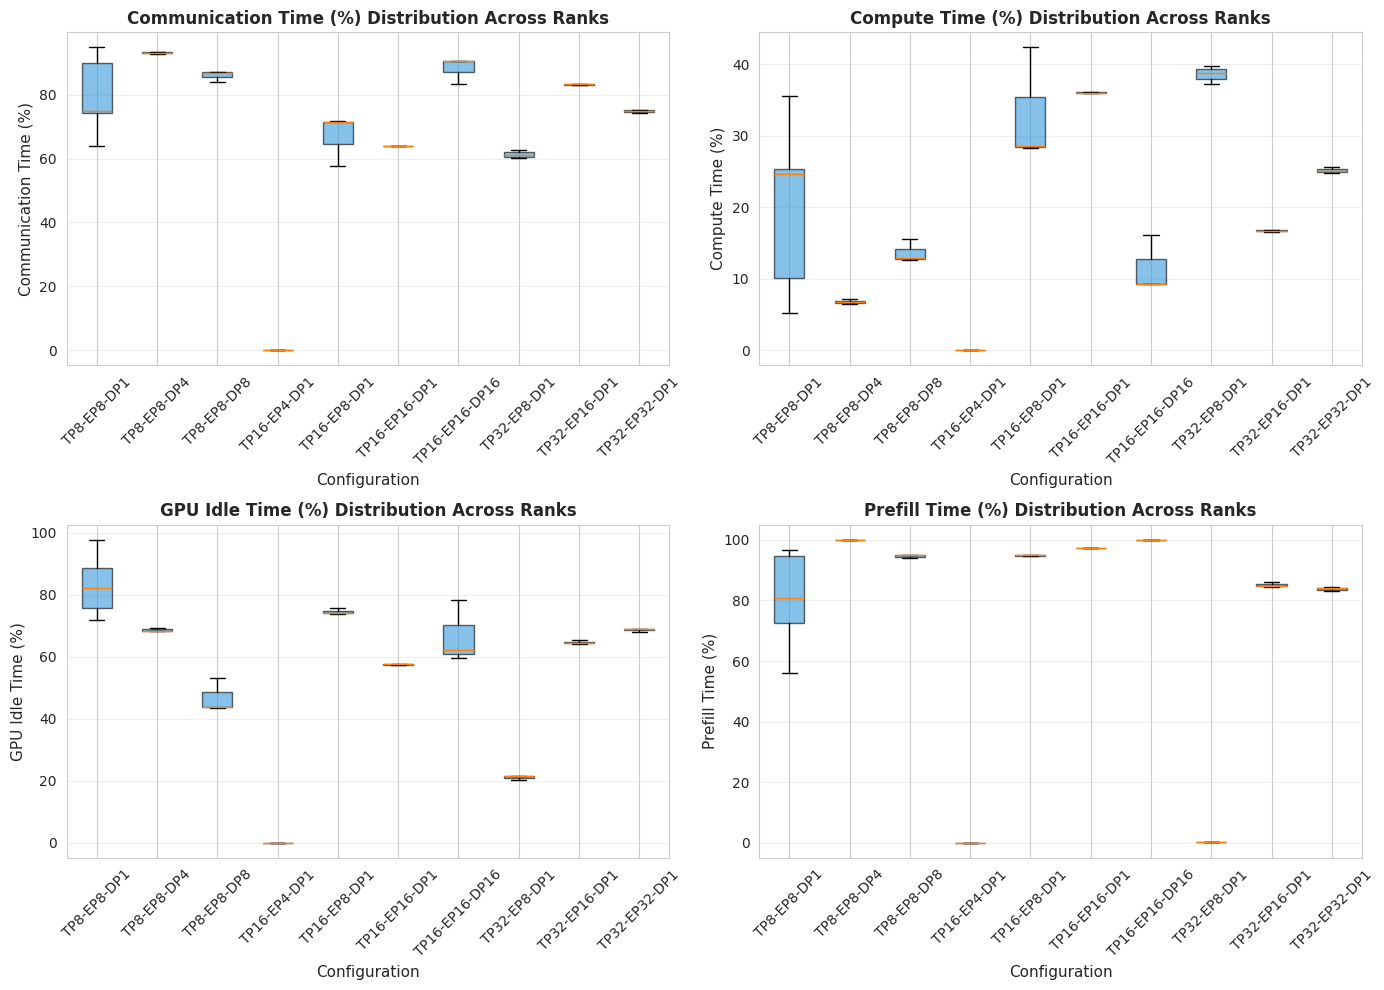


Saved: figures/per_rank_variance.png


In [8]:
# Box plot showing variance across ranks for each configuration
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ('communication_time_pct', 'Communication Time (%)', axes[0, 0]),
    ('compute_time_pct', 'Compute Time (%)', axes[0, 1]),
    ('gpu_idle_pct', 'GPU Idle Time (%)', axes[1, 0]),
    ('prefill_time_pct', 'Prefill Time (%)', axes[1, 1])
]

for metric, title, ax in metrics:
    # Prepare data for box plot
    plot_data = []
    labels = []
    
    for _, config_row in agg_data.iterrows():
        config_filter = (
            (df_summary['tp_size'] == config_row['tp_size']) &
            (df_summary['ep_size'] == config_row['ep_size']) &
            (df_summary['dp_size'] == config_row['dp_size'])
        )
        values = df_summary[config_filter][metric].dropna().values
        if len(values) > 0:
            plot_data.append(values)
            labels.append(config_row['config'])
    
    if plot_data:
        bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('#3498db')
            patch.set_alpha(0.6)
        
        ax.set_ylabel(title, fontsize=11)
        ax.set_xlabel('Configuration', fontsize=11)
        ax.set_title(f'{title} Distribution Across Ranks', fontsize=12, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'per_rank_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {output_dir / 'per_rank_variance.png'}")

## 7. Summary Statistics Table

In [9]:
# Create summary table
summary_table = agg_data[[
    'config', 
    'compute_time_pct', 
    'communication_time_pct', 
    'memory_time_pct',
    'gpu_idle_pct'
]].copy()

# Add total GPU count
summary_table['total_gpus'] = agg_data['total_gpus']

# Round for display
for col in ['compute_time_pct', 'communication_time_pct', 'memory_time_pct', 'gpu_idle_pct']:
    summary_table[col] = summary_table[col].round(2)

# Rename columns
summary_table.columns = [
    'Configuration', 
    'Compute (%)', 
    'Communication (%)', 
    'Memory (%)',
    'GPU Idle (%)',
    'Total GPUs'
]

print("\n" + "="*80)
print("SUMMARY STATISTICS BY CONFIGURATION")
print("="*80)
print(summary_table.to_string(index=False))
print("="*80)

# Save to CSV
summary_table.to_csv(output_dir / 'summary_statistics.csv', index=False)
print(f"\nSaved: {output_dir / 'summary_statistics.csv'}")


SUMMARY STATISTICS BY CONFIGURATION
 Configuration  Compute (%)  Communication (%)  Memory (%)  GPU Idle (%)  Total GPUs
   TP8-EP8-DP1        20.13              79.62        0.25         83.05           8
   TP8-EP8-DP4         6.76              93.09        0.15         68.63           8
   TP8-EP8-DP8        13.67              86.01        0.32         46.83           8
  TP16-EP4-DP1         0.00               0.00        0.00          0.00          16
  TP16-EP8-DP1        33.05              66.93        0.02         74.51          16
 TP16-EP16-DP1        36.01              63.97        0.02         57.45          16
TP16-EP16-DP16        11.52              88.19        0.29         66.66          16
  TP32-EP8-DP1        38.57              61.33        0.10         21.02          32
 TP32-EP16-DP1        16.71              83.28        0.01         64.60          32
 TP32-EP32-DP1        25.13              74.86        0.01         68.64          32

Saved: figures/summary_stat

## 8. Cross-Rank Analysis (if available)

Cross-rank data analysis:


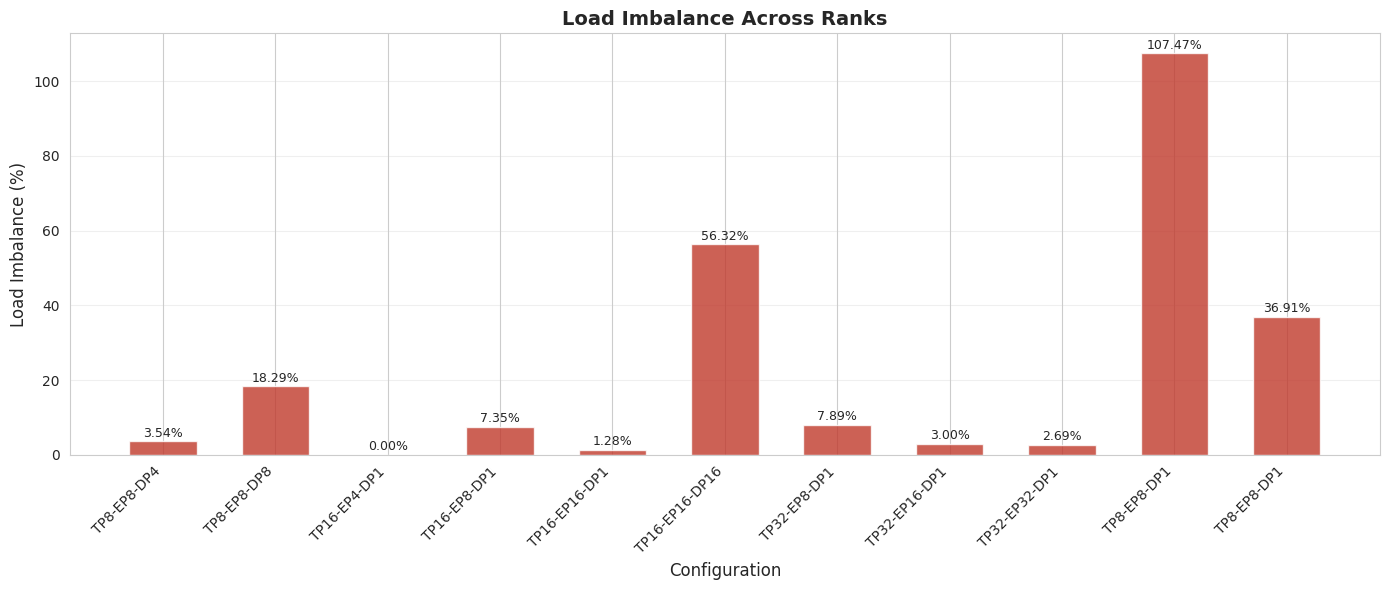


Saved: figures/load_imbalance.png


In [10]:
if has_cross_rank:
    print("Cross-rank data analysis:")
    
    # Load imbalance analysis
    if 'load_imbalance_pct' in df_cross.columns:
        fig, ax = plt.subplots(figsize=(14, 6))
        
        df_cross['config'] = df_cross.apply(
            lambda x: f"TP{int(x['tp_size'])}-EP{int(x['ep_size'])}-DP{int(x['dp_size'])}", 
            axis=1
        )
        
        x = np.arange(len(df_cross))
        bars = ax.bar(x, df_cross['load_imbalance_pct'], width=0.6, color='#c0392b', alpha=0.8)
        
        ax.set_ylabel('Load Imbalance (%)', fontsize=12)
        ax.set_xlabel('Configuration', fontsize=12)
        ax.set_title('Load Imbalance Across Ranks', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(df_cross['config'], rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for bar, val in zip(bars, df_cross['load_imbalance_pct']):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(output_dir / 'load_imbalance.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nSaved: {output_dir / 'load_imbalance.png'}")
else:
    print("\nCross-rank analysis will be available after export completes.")
    print("Run this notebook again after all trace files are processed.")

## Summary

All figures have been generated and saved to the `figures/` directory:

1. **kernel_category_breakdown.png** - Stacked bar chart of compute/communication/memory percentages
2. **gpu_idle_time.png** - GPU idle time comparison across configurations
3. **prefill_decode_distribution.png** - Prefill vs decode phase distribution
4. **combined_category_idle.png** - Combined view of category breakdown and idle time
5. **per_rank_variance.png** - Box plots showing variance across ranks
6. **load_imbalance.png** - Load imbalance analysis (if cross-rank data available)
7. **summary_statistics.csv** - Numerical summary table

These visualizations help identify:
- Configurations with high communication overhead
- GPU utilization efficiency
- Load balancing issues across ranks
- Phase distribution patterns